# 15 — SBERT–Accuracy Dissociation

**Finding**: InternVL and LLaVA models score close to humans on SBERT (semantic similarity of answers) but significantly above humans in accuracy (agreement with ground truth), under blind and inst-blind conditions.

**Hypothesis**: Models exploit dataset-specific linguistic priors — they answer similarly *in style* to humans (same semantic space), but are better calibrated to the VQA answer distribution, either from dataset contamination or corpus-frequency bias.

**This notebook**:
1. Per-question accuracy gap (model − human)
2. Per-question SBERT similarity (model answer ↔ human answer)
3. Scatter: accuracy gap vs SBERT similarity, coloured by model group
4. Characterise high-gap / high-SBERT questions (entity type, answer, question text)
5. Compare within model groups: who drives the dissociation?
6. Linguistic prior signal: is the ground truth answer a highly frequent VQA token?

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))
from figures.helpers import save_fig

from utils.constants import GROUP_COLORS, GROUP_ORDER

EXPORTS = ROOT / 'analysis/session2/exports'
VARIANT = 'C'
CONDITION = 'inst_blind'  # primary; repeat for blind

OUT_DIR = ROOT / 'figures/supplementary/sbert_gap'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load data

In [48]:
blind_df      = pd.read_csv(EXPORTS / 'responses_model_blind.csv')
inst_blind_df = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
human_df      = pd.read_csv(EXPORTS / 'responses_human.csv')
pair_cache    = pd.read_parquet(EXPORTS / 'pair_cache.parquet')

# Restrict to variant C
blind_vC      = blind_df[blind_df['variant'] == VARIANT].copy()
inst_blind_vC = inst_blind_df[inst_blind_df['variant'] == VARIANT].copy()
human_vC      = human_df[human_df['variant'] == VARIANT].copy()
pc_vC         = pair_cache[pair_cache['variant'] == VARIANT].copy()

print(f'Model blind vC: {len(blind_vC)} rows, {blind_vC["model"].nunique()} models')
print(f'Model inst_blind vC: {len(inst_blind_vC)} rows')
print(f'Human vC: {len(human_vC)} rows, {human_vC["participant"].nunique()} participants')
print(f'Pair cache vC: {len(pc_vC)} pairs')


Model blind vC: 2605 rows, 24 models
Model inst_blind vC: 2605 rows
Human vC: 4520 rows, 40 participants
Pair cache vC: 182618 pairs


## 2. Per-question accuracy: model vs human

`responses_model_*.csv` already has `human_avg_acc` (mean human accuracy over the study participants) and `accuracy` (model accuracy) per question × model row.

In [49]:
def make_acc_df(df, condition_label):
    """Per question × model: accuracy gap = model_acc - human_avg_acc."""
    d = df.copy()
    d['acc_gap'] = d['accuracy'] - d['human_avg_acc']
    d['condition'] = condition_label
    return d

blind_acc      = make_acc_df(blind_vC, 'blind')
inst_blind_acc = make_acc_df(inst_blind_vC, 'inst_blind')
acc_df = pd.concat([blind_acc, inst_blind_acc], ignore_index=True)

# Summary by model × condition
gap_summary = acc_df.groupby(['model_group', 'model', 'condition']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    n_questions=('question_id', 'nunique')
).reset_index()

# Show top gaps
inst_gaps = gap_summary[gap_summary['condition'] == 'inst_blind'].sort_values('mean_acc_gap', ascending=False)
print('\nInst-blind accuracy gap (model − human), top models:')
print(inst_gaps[['model_group', 'model', 'mean_model_acc', 'mean_human_acc', 'mean_acc_gap']].head(20).to_string(index=False))


Inst-blind accuracy gap (model − human), top models:
           model_group              model  mean_model_acc  mean_human_acc  mean_acc_gap
                   VLM      LLaVA-Mistral        0.536873        0.262242      0.274631
  VLM backbone decoder     LLaVA-1.5 (LM)        0.536873        0.262242      0.274631
  VLM backbone decoder LLaVA-Mistral (LM)        0.536873        0.262242      0.274631
                   VLM       LLaVA-Vicuna        0.516224        0.262242      0.253982
                   VLM        Qwen3-VL-8B        0.473214        0.262054      0.211161
                   VLM       LLaVA-1.5-7B        0.471976        0.262242      0.209735
                   VLM        InternVL-2B        0.445428        0.262242      0.183186
  VLM backbone decoder  LLaVA-Vicuna (LM)        0.445428        0.262242      0.183186
                   VLM        InternVL-8B        0.371681        0.262242      0.109440
                   VLM        InternVL-1B        0.369048        0

In [50]:
# Group-level summary
grp_gap = acc_df.groupby(['model_group', 'condition']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
).reset_index()

print('Group-level accuracy gap:')
print(grp_gap.sort_values(['condition','mean_acc_gap'], ascending=[True, False]).to_string(index=False))

Group-level accuracy gap:
           model_group  condition  mean_model_acc  mean_human_acc  mean_acc_gap
  VLM backbone decoder      blind        0.506391        0.262242      0.244149
                   VLM      blind        0.455006        0.262548      0.192459
        standalone LLM      blind        0.167761        0.261132     -0.093372
standalone LLM (think)      blind        0.161042        0.262685     -0.101643
  VLM backbone decoder inst_blind        0.506391        0.262242      0.244149
                   VLM inst_blind        0.455006        0.262548      0.192459
        standalone LLM inst_blind        0.167761        0.261132     -0.093372
standalone LLM (think) inst_blind        0.161042        0.262685     -0.101643


## 3. Per-question SBERT: model answer ↔ human answer (HM pairs)

In [51]:
# HM pairs: subject_1=human, subject_2=model
hm = pc_vC[pc_vC['pair_type'] == 'HM'].copy()

# Mean SBERT per question × model (averaging over all human raters paired with this model)
hm_sbert = hm.groupby(['question_id', 'subject_2', 'subject_group_2']).agg(
    mean_sbert=('sbert_score', 'mean'),
    mean_chrf=('chrf_score', 'mean'),
    mean_exact=('exact_score', 'mean'),
    n_pairs=('sbert_score', 'count')
).reset_index().rename(columns={'subject_2': 'model', 'subject_group_2': 'model_group'})

print(f'HM SBERT table: {len(hm_sbert)} rows ({hm_sbert["model"].nunique()} models × {hm_sbert["question_id"].nunique()} questions)')

HM SBERT table: 2291 rows (27 models × 88 questions)


## 4. Join accuracy gap + SBERT per question × model

In [52]:
# Join inst_blind accuracy with HM SBERT
joined = inst_blind_acc.merge(
    hm_sbert[['question_id', 'model', 'mean_sbert', 'mean_chrf', 'mean_exact']],
    on=['question_id', 'model'],
    how='inner'
)
print(f'Joined: {len(joined)} rows')

# Also compute question-level: mean across models in each group
q_group = joined.groupby(['question_id', 'model_group', 'ent', 'op', 'question_en', 'gt', 'human_avg_acc']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    mean_sbert=('mean_sbert', 'mean'),
    mean_chrf=('mean_chrf', 'mean'),
).reset_index()

print(q_group['model_group'].value_counts())

Joined: 2027 rows
model_group
VLM                       88
VLM backbone decoder      88
standalone LLM            88
standalone LLM (think)    88
Name: count, dtype: int64


## 5. Scatter: accuracy gap vs SBERT, per model group

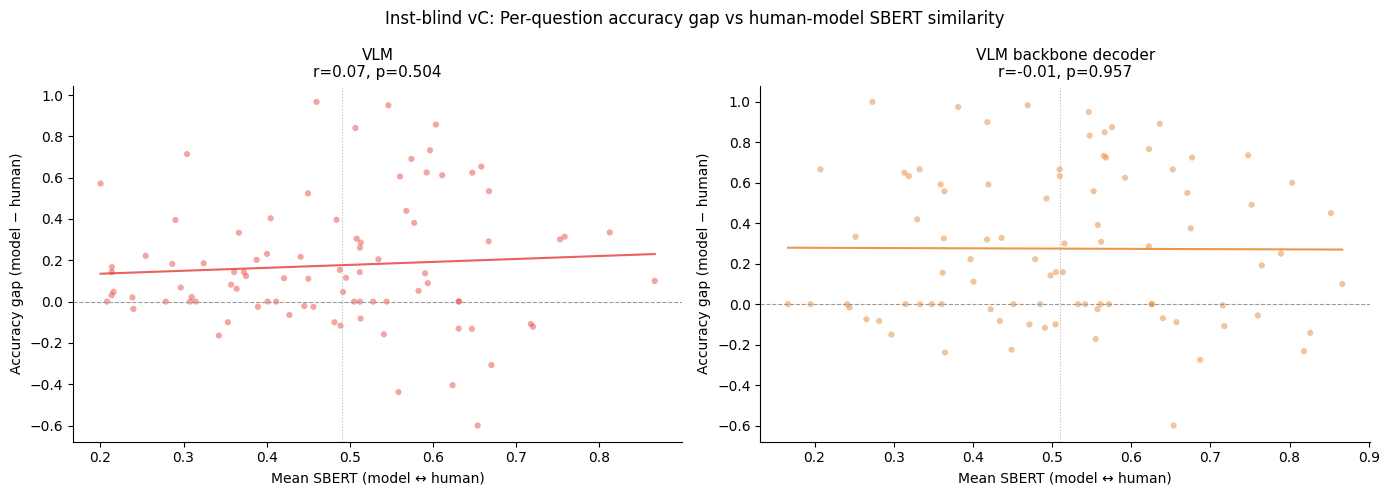

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grp in zip(axes, ['VLM', 'VLM backbone decoder']):
    sub = q_group[q_group['model_group'] == grp]
    color = GROUP_COLORS.get(grp, '#888')
    ax.scatter(sub['mean_sbert'], sub['mean_acc_gap'],
               alpha=0.45, s=20, color=color, edgecolors='none')
    # reference lines
    ax.axhline(0, color='#999', lw=0.8, ls='--')
    ax.axvline(sub['mean_sbert'].median(), color='#bbb', lw=0.8, ls=':')
    # regression
    x, y = sub['mean_sbert'].values, sub['mean_acc_gap'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 5:
        r, p = stats.pearsonr(x[mask], y[mask])
        m, b = np.polyfit(x[mask], y[mask], 1)
        xr = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(xr, m*xr + b, color=color, lw=1.5, alpha=0.8)
        ax.set_title(f'{grp}\nr={r:.2f}, p={p:.3f}', fontsize=11)
    ax.set_xlabel('Mean SBERT (model ↔ human)', fontsize=10)
    ax.set_ylabel('Accuracy gap (model − human)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Inst-blind vC: Per-question accuracy gap vs human-model SBERT similarity', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cluster scatter: all groups, three metrics side by side ───────────────────
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=1.5, fill=True, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_rx = np.sqrt(1 + pearson); ell_ry = np.sqrt(1 - pearson)
    kw = dict(width=ell_rx * 2, height=ell_ry * 2)
    if not fill: kw['fill'] = False
    ellipse = Ellipse((0, 0), **kw, **kwargs)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)

# Join all three HM metrics
hm_all = pc_vC[pc_vC['pair_type'] == 'HM'].copy()
hm_agg = (hm_all.groupby(['question_id', 'subject_2'])
          [['sbert_score', 'chrf_score', 'exact_score']].mean().reset_index()
          .rename(columns={'subject_2': 'model'}))
joined_all = inst_blind_acc.merge(hm_agg, on=['question_id', 'model'], how='inner')
q_all = (joined_all.groupby(['question_id', 'model_group'])
         [['acc_gap', 'sbert_score', 'chrf_score', 'exact_score']].mean().reset_index())

METRICS = [
    ('sbert_score', 'SBERT cosine'),
    ('chrf_score',  'chrF'),
    ('exact_score', 'Exact match'),
]
GROUP_LABEL = {
    'VLM':                    'VLM',
    'VLM backbone decoder':   'VLM backbone\n(LM)',
    'standalone LLM':         'Standalone LLM',
    'standalone LLM (think)': 'SA-LLM (think)',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (metric_col, metric_name) in zip(axes, METRICS):
    for grp in GROUP_ORDER:
        sub = q_all[q_all['model_group'] == grp]
        if sub.empty: continue
        x = sub[metric_col].values; y = sub['acc_gap'].values
        mask = ~(np.isnan(x) | np.isnan(y)); x, y = x[mask], y[mask]
        color = GROUP_COLORS.get(grp, '#888')
        label = GROUP_LABEL.get(grp, grp)
        confidence_ellipse(x, y, ax, n_std=1.5, fill=True,
                           alpha=0.12, facecolor=color, zorder=1)
        confidence_ellipse(x, y, ax, n_std=1.5, fill=False,
                           alpha=0.70, edgecolor=color,
                           linewidth=1.5, linestyle='--', zorder=2)
        ax.scatter(x, y, alpha=0.25, s=10, color=color, edgecolors='none', zorder=3)
        ax.scatter(np.mean(x), np.mean(y), s=80, color=color, zorder=5,
                   edgecolors='white', linewidths=1.1)
        ax.annotate(label, (np.mean(x), np.mean(y)),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=color, fontweight='bold', zorder=6)
        r, p = stats.pearsonr(x, y)
    ax.axhline(0, color='#777', lw=1.0, ls='--', zorder=0)
    ax.set_xlabel(f'{metric_name} (model ↔ human)', fontsize=10)
    ax.set_title(metric_name, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Accuracy gap (model − human)', fontsize=10)
fig.suptitle('Inst-blind vC: HM agreement vs accuracy advantage — three metrics\n'
             '(dots = questions, ellipses = 1.5σ, markers = group centroids)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 6. Model-level summary: SBERT vs accuracy gap trade-off

Reproduces the 2D view that prompted this notebook — which models are high-SBERT + high-gap?

In [ ]:
# Per-model summary
model_summary = joined.groupby(['model', 'model_group']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    mean_sbert=('mean_sbert', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5.5))

for grp in GROUP_ORDER:
    sub = model_summary[model_summary['model_group'] == grp]
    if sub.empty:
        continue
    color = GROUP_COLORS.get(grp, '#888')
    ax.scatter(sub['mean_sbert'], sub['mean_acc_gap'],
               color=color, s=90, zorder=3, edgecolors='white', linewidths=0.7)
    for _, row in sub.iterrows():
        ax.annotate(row['model'],
                    (row['mean_sbert'], row['mean_acc_gap']),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=7, color=color, va='center')

ax.axhline(0, color='#777', lw=1, ls='--')
ax.axvline(model_summary['mean_sbert'].median(), color='#ccc', lw=0.8, ls=':')

# Add quadrant labels
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[1]*0.98, ylim[1]*0.9, 'High similarity\nHigh advantage',
        ha='right', fontsize=8, color='#555', style='italic')
ax.text(xlim[0]+(xlim[1]-xlim[0])*0.02, ylim[1]*0.9, 'Low similarity\nHigh advantage',
        ha='left', fontsize=8, color='#555', style='italic')

legend_patches = [mpatches.Patch(color=GROUP_COLORS.get(g,'#888'), label=g) for g in GROUP_ORDER]
ax.legend(handles=legend_patches, fontsize=8, frameon=True)
ax.set_xlabel('Mean SBERT (model ↔ human)', fontsize=11)
ax.set_ylabel('Accuracy gap (model − human)', fontsize=11)
ax.set_title('Per-model: answer semantic similarity vs accuracy advantage (inst-blind vC)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nModel summary:')
print(model_summary.sort_values('mean_acc_gap', ascending=False)[['model_group','model','mean_sbert','mean_model_acc','mean_human_acc','mean_acc_gap']].to_string(index=False))

## 7. Characterise high-gap questions

Which questions have the largest model-vs-human accuracy gap AND high SBERT (i.e., model and human answers look similar but models are correct more often)?

In [56]:
# Focus on VLM group (the main finding)
vlm_q = q_group[q_group['model_group'] == 'VLM'].copy()

# Quadrants based on medians
sbert_med  = vlm_q['mean_sbert'].median()
gap_med    = vlm_q['mean_acc_gap'].median()

vlm_q['quadrant'] = 'other'
vlm_q.loc[(vlm_q['mean_sbert'] >= sbert_med) & (vlm_q['mean_acc_gap'] >= gap_med), 'quadrant'] = 'high_sim_high_gap'
vlm_q.loc[(vlm_q['mean_sbert'] >= sbert_med) & (vlm_q['mean_acc_gap'] < gap_med),  'quadrant'] = 'high_sim_low_gap'
vlm_q.loc[(vlm_q['mean_sbert'] < sbert_med)  & (vlm_q['mean_acc_gap'] >= gap_med), 'quadrant'] = 'low_sim_high_gap'
vlm_q.loc[(vlm_q['mean_sbert'] < sbert_med)  & (vlm_q['mean_acc_gap'] < gap_med),  'quadrant'] = 'low_sim_low_gap'

print('VLM quadrant counts:')
print(vlm_q['quadrant'].value_counts())

print('\n── Entity type distribution per quadrant ──')
print(vlm_q.groupby(['quadrant', 'ent']).size().unstack(fill_value=0))

print('\n── Op type distribution per quadrant ──')
print(vlm_q.groupby(['quadrant', 'op']).size().unstack(fill_value=0))

VLM quadrant counts:
quadrant
low_sim_low_gap      24
high_sim_high_gap    24
low_sim_high_gap     20
high_sim_low_gap     20
Name: count, dtype: int64

── Entity type distribution per quadrant ──
ent                animal  food  object  other  person  place  product  text  \
quadrant                                                                       
high_sim_high_gap       1     5       8      1       6      0        2     0   
high_sim_low_gap        4     1       5      2       3      2        1     2   
low_sim_high_gap        3     0       5      2       7      0        1     1   
low_sim_low_gap         4     5       5      2       4      1        1     1   

ent                vehicle  
quadrant                    
high_sim_high_gap        1  
high_sim_low_gap         0  
low_sim_high_gap         1  
low_sim_low_gap          1  

── Op type distribution per quadrant ──
op                 act  attr  cause  comp  count  ident  know  spat  temp  \
quadrant                      

In [57]:
# Sample high-gap + high-SBERT questions: models are semantically close to humans but much more accurate
high_q = vlm_q[vlm_q['quadrant'] == 'high_sim_high_gap'].sort_values('mean_acc_gap', ascending=False)

print(f'High-sim / high-gap VLM questions (N={len(high_q)}):')
cols = ['question_en', 'gt', 'human_avg_acc', 'mean_model_acc', 'mean_acc_gap', 'mean_sbert', 'ent', 'op']
print(high_q[cols].head(20).to_string(index=False, max_colwidth=60))

High-sim / high-gap VLM questions (N=24):
                                         question_en                                                           gt  human_avg_acc  mean_model_acc  mean_acc_gap  mean_sbert     ent    op
                    How many hearts are on the desk?                        0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.050000        1.000000      0.950000    0.546320  object count
         How many bottles of water are on the table?                        0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.000000        0.857143      0.857143    0.603448  object count
                 How many shoes are under the table?                        0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0       0.016667        0.857143      0.840476    0.506622 product count
                  How many people are wearing peach?              0 | many | many | 10 | 0 | 10 | 16 | 4 | 15 | 0       0.125000        0.857143      0.732143    0.596288  person count
                           How ma

In [58]:
# Compare: low-gap questions (model≈human accuracy, any SBERT)
low_gap_q = vlm_q[vlm_q['mean_acc_gap'] < 0].sort_values('mean_acc_gap')
print(f'Questions where models do WORSE than humans (gap<0): {len(low_gap_q)}')
print(low_gap_q[cols].head(15).to_string(index=False, max_colwidth=60))

Questions where models do WORSE than humans (gap<0): 19
                                             question_en                                                           gt  human_avg_acc  mean_model_acc  mean_acc_gap  mean_sbert     ent    op
                    How many earrings does the man have?                        2 | 1 | 1 | 2 | 2 | 2 | 2 | 2 | 2 | 2       0.600000        0.000000     -0.600000    0.653580 product count
                    How many of these people are female?                        3 | 2 | 2 | 2 | 3 | 2 | 2 | 1 | 2 | 1       0.533333        0.095238     -0.438095    0.558473  person count
                      How many hot dogs are on this bun?                        2 | 2 | 1 | 2 | 2 | 2 | 2 | 1 | 2 | 2       0.500000        0.095238     -0.404762    0.623466    food count
            How many people touching the elephant trunk?                        2 | 2 | 2 | 2 | 2 | 2 | 1 | 2 | 2 | 2       0.450000        0.142857     -0.307143    0.670099  person count

## 8. Linguistic prior signal: op/ent breakdown

The accuracy gap is driven by question structure → answer mapping learned from VQA-scale training.
- **count** questions: models learned "0" or "1" is the modal answer when the object isn't visible
- **attr** questions: color/type/material priors (e.g., "white" for appliances, "tennis" for shoes)
- **spat** questions: left/right/behind require visual grounding — no strong linguistic prior

We expect the gap to be concentrated in `count` and `attr`, and near-zero or negative for `spat`.

In [59]:
# Accuracy gap by op type — all groups
op_gap = joined.groupby(['model_group', 'op']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    mean_sbert=('mean_sbert', 'mean'),
    n=('question_id', 'nunique'),
).reset_index()

print('Accuracy gap by op type (inst-blind vC):')
pivot = op_gap.pivot(index='op', columns='model_group', values='mean_acc_gap').round(3)
print(pivot.to_string())

Accuracy gap by op type (inst-blind vC):
model_group    VLM  VLM backbone decoder  standalone LLM  standalone LLM (think)
op                                                                              
act          0.110                 0.428          -0.151                  -0.283
attr         0.179                 0.256          -0.019                  -0.011
cause        0.182                 0.325          -0.008                   0.058
comp         0.124                 0.156          -0.070                  -0.067
count        0.257                 0.350          -0.037                  -0.044
ident        0.098                 0.195           0.066                   0.019
know         0.116                 0.188          -0.062                  -0.012
spat         0.170                 0.365           0.007                  -0.002
temp         0.015                 0.017          -0.067                  -0.072
text         0.118                 0.118           0.002            

In [ ]:
# ── Entity-wise breakdown (self-contained) ────────────────────────────────────
_ent_pair = pd.read_parquet(EXPORTS / "pair_cache.parquet")
_ent_pc = _ent_pair[(_ent_pair["variant"] == "C") & (_ent_pair["pair_type"] == "HM")].copy()
_ent_hm = (_ent_pc.groupby(["question_id", "subject_2"])
           [["sbert_score", "chrf_score", "exact_score"]].mean()
           .reset_index().rename(columns={"subject_2": "model"}))
_ent_base = pd.read_csv(EXPORTS / "responses_model_inst_blind.csv")
_ent_base = _ent_base[_ent_base["variant"] == "C"].copy()
_ent_base["acc_gap"] = _ent_base["accuracy"] - _ent_base["human_avg_acc"]
_ent_joined = _ent_base.merge(_ent_hm, on=["question_id", "model"], how="inner")

ent_order_all = (
    _ent_joined.groupby("question_id")["ent"].first().value_counts().index.tolist()
)

delta_rows = []
for ent in ent_order_all:
    sub_vlm = _ent_joined[(_ent_joined["ent"] == ent) & (_ent_joined["model_group"] == "VLM")]
    sub_llm = _ent_joined[(_ent_joined["ent"] == ent) & (_ent_joined["model_group"] == "standalone LLM")]
    n_q = _ent_joined[_ent_joined["ent"] == ent]["question_id"].nunique()
    if sub_vlm.empty or sub_llm.empty or n_q < 3:
        continue
    delta_rows.append({
        "ent":         ent,
        "n_q":         n_q,
        "delta_sbert": sub_vlm["sbert_score"].mean() - sub_llm["sbert_score"].mean(),
        "delta_gap":   sub_vlm["acc_gap"].mean()     - sub_llm["acc_gap"].mean(),
        "vlm_sbert":   sub_vlm["sbert_score"].mean(),
        "llm_sbert":   sub_llm["sbert_score"].mean(),
        "vlm_gap":     sub_vlm["acc_gap"].mean(),
        "llm_gap":     sub_llm["acc_gap"].mean(),
    })
delta_df = pd.DataFrame(delta_rows).sort_values("delta_gap", ascending=False)

ent_colors = {
    "object": "#455A64", "person": "#E53935", "animal": "#388E3C",
    "food":   "#FB8C00", "product": "#8E24AA", "other":  "#039BE5",
    "vehicle":"#6D4C41", "place":  "#00897B",  "text":   "#F06292",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: Δ scatter per entity ────────────────────────────────────────────────
ax = axes[0]
for _, row in delta_df.iterrows():
    color = ent_colors.get(row["ent"], "#888")
    ax.scatter(row["delta_sbert"], row["delta_gap"],
               s=row["n_q"] * 14, color=color, zorder=3,
               edgecolors="white", linewidths=0.8, alpha=0.9)
    ax.annotate(f'{row["ent"]}\n(n={row["n_q"]:g})',
                (row["delta_sbert"], row["delta_gap"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=7.5, color=color)
ax.axhline(0, color="#aaa", lw=0.8, ls="--")
ax.axvline(0, color="#aaa", lw=0.8, ls="--")
ax.set_xlabel("ΔSBERT (VLM − Standalone LLM)", fontsize=10)
ax.set_ylabel("ΔAccuracy gap (VLM − Standalone LLM)", fontsize=10)
ax.set_title("Entity-level VLM advantage\nover standalone LLMs", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0.02, 0.97, "bubble size ∝ n questions",
        transform=ax.transAxes, fontsize=7.5, color="#777", va="top")

# ── Right: SBERT bars per entity ──────────────────────────────────────────────
ax = axes[1]
x = np.arange(len(delta_df)); w = 0.32
vlm_color = GROUP_COLORS.get("VLM", "#E53935")
llm_color  = GROUP_COLORS.get("standalone LLM", "#1976D2")
for i, (_, row) in enumerate(delta_df.iterrows()):
    ax.bar(i - w/2, row["vlm_sbert"], w * 0.9, color=vlm_color, alpha=0.85,
           label="VLM" if i == 0 else "_")
    ax.bar(i + w/2, row["llm_sbert"], w * 0.9, color=llm_color, alpha=0.85,
           label="Standalone LLM" if i == 0 else "_")
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{r["ent"]}\n(n={r["n_q"]:g})' for _, r in delta_df.iterrows()],
    fontsize=8)
ax.set_ylabel("Mean SBERT (model ↔ human)", fontsize=10)
ax.set_title("SBERT by entity:\nVLM vs Standalone LLM", fontsize=10)
ax.legend(fontsize=8, frameon=True)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Inst-blind vC: Entity-wise SBERT similarity and accuracy advantage", fontsize=11)
plt.tight_layout()
plt.show()

print("\nSummary (sorted by Δgap):")
print(f"{'Entity':<10}  {'n_q':>4}  {'ΔSBERT':>8}  {'ΔGap':>8}")
print("-" * 38)
for _, row in delta_df.iterrows():
    print(f"{row['ent']:<10}  {row['n_q']:4g}  {row['delta_sbert']:+8.3f}  {row['delta_gap']:+8.3f}")

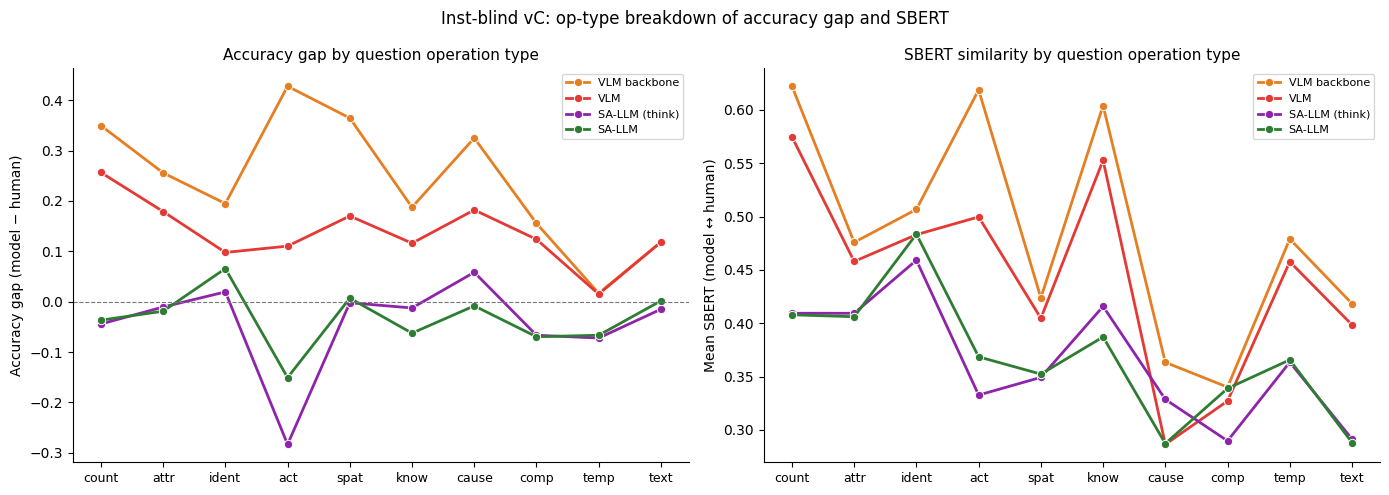

In [61]:
OP_ORDER = ['count', 'attr', 'ident', 'act', 'spat', 'know', 'cause', 'comp', 'temp', 'text']
OP_ORDER = [o for o in OP_ORDER if o in op_gap['op'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy gap by op, one line per model group
ax = axes[0]
for grp in GROUP_ORDER:
    sub = op_gap[op_gap['model_group'] == grp].set_index('op').reindex(OP_ORDER)
    color = GROUP_COLORS.get(grp, '#888')
    ax.plot(range(len(OP_ORDER)), sub['mean_acc_gap'].values,
            color=color, lw=2, marker='o', markersize=6,
            markeredgecolor='white', markeredgewidth=0.7,
            label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'backbone'))
ax.axhline(0, color='#777', lw=0.8, ls='--')
ax.set_xticks(range(len(OP_ORDER)))
ax.set_xticklabels(OP_ORDER, fontsize=9)
ax.set_ylabel('Accuracy gap (model − human)', fontsize=10)
ax.set_title('Accuracy gap by question operation type', fontsize=11)
ax.legend(fontsize=8, frameon=True)
ax.spines[['top', 'right']].set_visible(False)

# Right: SBERT by op, one line per model group
ax = axes[1]
for grp in GROUP_ORDER:
    sub = op_gap[op_gap['model_group'] == grp].set_index('op').reindex(OP_ORDER)
    color = GROUP_COLORS.get(grp, '#888')
    ax.plot(range(len(OP_ORDER)), sub['mean_sbert'].values,
            color=color, lw=2, marker='o', markersize=6,
            markeredgecolor='white', markeredgewidth=0.7,
            label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'backbone'))
ax.set_xticks(range(len(OP_ORDER)))
ax.set_xticklabels(OP_ORDER, fontsize=9)
ax.set_ylabel('Mean SBERT (model ↔ human)', fontsize=10)
ax.set_title('SBERT similarity by question operation type', fontsize=11)
ax.legend(fontsize=8, frameon=True)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Inst-blind vC: op-type breakdown of accuracy gap and SBERT', fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
# The key question: for count and attr questions, what is the model guessing?
# Show the modal model answer vs GT for high-gap op types

for op_type in ['count', 'attr', 'spat']:
    sub = joined[(joined['op'] == op_type) & (joined['model_group'] == 'VLM')]
    if sub.empty:
        continue
    # Aggregate to question level
    q_sub = sub.groupby(['question_id', 'question_en', 'gt', 'human_avg_acc']).agg(
        mean_model_acc=('accuracy', 'mean'),
        mean_acc_gap=('acc_gap', 'mean'),
    ).reset_index().sort_values('mean_acc_gap', ascending=False)
    print(f'\n── op={op_type} (n={len(q_sub)} questions) ──')
    print(f'  Mean acc gap: {q_sub["mean_acc_gap"].mean():.3f}')
    print(q_sub[['question_en', 'gt', 'human_avg_acc', 'mean_model_acc', 'mean_acc_gap']].head(8).to_string(index=False, max_colwidth=55))


── op=count (n=22 questions) ──
  Mean acc gap: 0.257
                                question_en                                              gt  human_avg_acc  mean_model_acc  mean_acc_gap
   How many apple trees are in the picture?           0 | 0 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.033333        1.000000      0.966667
           How many hearts are on the desk?           0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.050000        1.000000      0.950000
How many bottles of water are on the table?           0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.000000        0.857143      0.857143
        How many shoes are under the table?           0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0       0.016667        0.857143      0.840476
         How many people are wearing peach? 0 | many | many | 10 | 0 | 10 | 16 | 4 | 15 | 0       0.125000        0.857143      0.732143
                  How many bagels are here?           1 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0       0.166667        0.857143 

## 9. Blind vs inst-blind comparison

Does the SBERT–accuracy dissociation strengthen or weaken when the instruction is added?

In [63]:
# HM pairs for blind condition — need to check if pair_cache has blind condition
# pair_cache is built from inst_blind by default; check pair_type coverage
print('Pair cache pair types:', pair_cache['pair_type'].value_counts().to_dict())
# The accuracy gap comparison blind vs inst_blind
grp_both = acc_df.groupby(['model_group', 'condition']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
).reset_index().pivot(index='model_group', columns='condition', values=['mean_model_acc', 'mean_acc_gap'])
grp_both.columns = ['_'.join(c) for c in grp_both.columns]
grp_both['gap_delta'] = grp_both['mean_acc_gap_inst_blind'] - grp_both['mean_acc_gap_blind']
print('\nAccuracy gap: blind vs inst_blind (gap_delta = inst_blind − blind):')
print(grp_both[['mean_model_acc_blind','mean_model_acc_inst_blind',
                'mean_acc_gap_blind','mean_acc_gap_inst_blind','gap_delta']].to_string())

Pair cache pair types: {'HM': 274400, 'HH': 205920, 'MM': 66765}

Accuracy gap: blind vs inst_blind (gap_delta = inst_blind − blind):
                        mean_model_acc_blind  mean_model_acc_inst_blind  mean_acc_gap_blind  mean_acc_gap_inst_blind  gap_delta
model_group                                                                                                                    
VLM                                 0.455006                   0.455006            0.192459                 0.192459        0.0
VLM backbone decoder                0.506391                   0.506391            0.244149                 0.244149        0.0
standalone LLM                      0.167761                   0.167761           -0.093372                -0.093372        0.0
standalone LLM (think)              0.161042                   0.161042           -0.101643                -0.101643        0.0


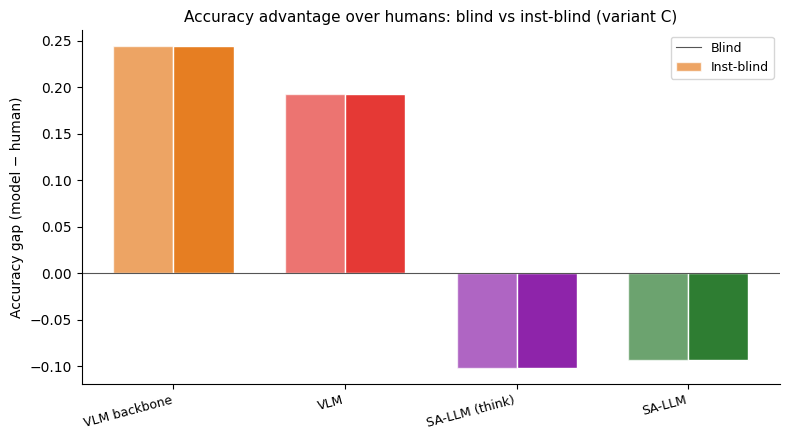

In [64]:
# Visualise: grouped bar chart of accuracy gap by condition
fig, ax = plt.subplots(figsize=(8, 4.5))

grp_bar = acc_df.groupby(['model_group', 'condition'])['acc_gap'].mean().reset_index()
conditions = ['blind', 'inst_blind']
x = np.arange(len(GROUP_ORDER))
w = 0.35

for i, cond in enumerate(conditions):
    vals = [grp_bar.loc[(grp_bar['model_group']==g) & (grp_bar['condition']==cond), 'acc_gap'].values
            for g in GROUP_ORDER]
    vals = [v[0] if len(v) else np.nan for v in vals]
    bars = ax.bar(x + (i - 0.5) * w, vals, w,
                  color=[GROUP_COLORS.get(g, '#888') for g in GROUP_ORDER],
                  alpha=0.7 if cond == 'blind' else 1.0,
                  label=cond,
                  edgecolor='white')

ax.axhline(0, color='#555', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'backbone') 
                    for g in GROUP_ORDER], fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Accuracy gap (model − human)', fontsize=10)
ax.set_title('Accuracy advantage over humans: blind vs inst-blind (variant C)', fontsize=11)
ax.legend(['Blind', 'Inst-blind'], fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Summary findings

In [65]:
print('═' * 70)
print('SUMMARY: SBERT–Accuracy Dissociation')
print('═' * 70)

for grp in GROUP_ORDER:
    sub = model_summary[model_summary['model_group'] == grp]
    if sub.empty:
        continue
    print(f'\n{grp}:')
    print(f'  SBERT (model↔human):  {sub["mean_sbert"].mean():.3f}')
    print(f'  Model accuracy:       {sub["mean_model_acc"].mean():.3f}')
    print(f'  Human accuracy:       {sub["mean_human_acc"].mean():.3f}')
    print(f'  Accuracy gap:         {sub["mean_acc_gap"].mean():+.3f}')

print('\n── Interpretation ──')
print('High SBERT + high accuracy gap = models use same semantic register')
print('as humans (short, concrete answers) but produce the VQA-calibrated')
print('answer more reliably. This is consistent with linguistic prior')
print('exploitation, not perceptual reasoning.')

══════════════════════════════════════════════════════════════════════
SUMMARY: SBERT–Accuracy Dissociation
══════════════════════════════════════════════════════════════════════

VLM backbone decoder:
  SBERT (model↔human):  0.509
  Model accuracy:       0.439
  Human accuracy:       0.165
  Accuracy gap:         +0.275

VLM:
  SBERT (model↔human):  0.478
  Model accuracy:       0.340
  Human accuracy:       0.165
  Accuracy gap:         +0.175

standalone LLM (think):
  SBERT (model↔human):  0.392
  Model accuracy:       0.138
  Human accuracy:       0.165
  Accuracy gap:         -0.027

standalone LLM:
  SBERT (model↔human):  0.377
  Model accuracy:       0.130
  Human accuracy:       0.151
  Accuracy gap:         -0.021

── Interpretation ──
High SBERT + high accuracy gap = models use same semantic register
as humans (short, concrete answers) but produce the VQA-calibrated
answer more reliably. This is consistent with linguistic prior
exploitation, not perceptual reasoning.
